In [1]:
from five_bar.five_bar import five_bar
import time
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams.update({
    "text.usetex": False,  # Use LaTeX for all text (if available)
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.autolayout": True
})
data_folder = os.path.abspath("data")


In [2]:
# Initialize robot
robot = five_bar(SERIAL_PORT="COM3", max_speed=2**15)
robot.set_control_mode("torque", 0, 0)


Initializing Robot...

Connecting to CAN bus COM3...
Successfully connected to CAN bus COM3!

Robot Initialized. 
Defaulting to control mode: 'torque'
Start threads to begin using the robot

Control Mode set to 'torque'. Setting targets to [0, 0]



In [ ]:
#robot.write_PID_write_command(100, 50, 100, 20, 100,5)

[577, 50, 0, 100, 50, 100, 20, 100, 5]
[578, 50, 0, 100, 50, 100, 20, 100, 5]


In [3]:
robot.start()

Starting Read/write threads...
Read/write threads started!



Measure Dry Friction

In [ ]:

num_trials = 20
torque_step = 0.01  # Nm per step
max_torque = 1.0    # Nm safety limit
speed_threshold = 1  # deg/s threshold for motion

results_motor1 = []
results_motor2 = []

robot.set_control_mode("torque")

# --- Experiment for Motor 1 ---
print("Starting static friction experiment for Motor 1")

for trial in range(num_trials):
    current_torque = 0.0

    while current_torque <= max_torque:
        robot.set_target( current_torque, 0.0)
        time.sleep(0.2)

        motor_data = robot.get_motors_data()
        speed1 = motor_data["speed"][0]

        if abs(speed1) > speed_threshold:
            print(f"Trial {trial}: Motor 1 started moving at {current_torque:.3f} Nm")
            results_motor1.append({
                'trial': trial,
                'breakaway_torque': current_torque
            })
            break

        current_torque += torque_step

    robot.set_target(0, 0)
    time.sleep(2)

# --- Experiment for Motor 2 ---
print("\nStarting static friction experiment for Motor 2")

for trial in range(num_trials):
    current_torque = 0.0

    while current_torque <= max_torque:
        robot.set_target( 0.0, current_torque)
        time.sleep(0.2)

        motor_data = robot.get_motors_data()
        speed2 = motor_data["speed"][1]

        if abs(speed2) > speed_threshold:
            print(f"Trial {trial}: Motor 2 started moving at {current_torque:.3f} Nm")
            results_motor2.append({
                'trial': trial,
                'breakaway_torque': current_torque
            })
            break

        current_torque += torque_step

    robot.set_target(0, 0)
    time.sleep(2)

# Convert to DataFrames
df_motor1 = pd.DataFrame(results_motor1)
df_motor2 = pd.DataFrame(results_motor2)


In [ ]:
df_motor1.to_csv(os.path.join(data_folder, 'motor1_dry.csv'), index=False)
df_motor2.to_csv(os.path.join(data_folder, 'motor2_dry.csv'), index=False)

In [ ]:
from scipy.stats import t

# Combinar en DataFrame para boxplot
df_box = pd.DataFrame({
    'Motor 1': df_motor1['breakaway_torque'],
    'Motor 2': df_motor2['breakaway_torque']
})

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(8, 6))

df_box.boxplot(ax=ax, grid=True, notch=False, showfliers=False)

ax.set_title('Fricción Estática - Diagrama de Caja y Bigotes', fontsize=14, weight='bold')
ax.set_ylabel('Torque de fricción estática (Nm)')

plt.show()

resolution = 0.01  # Nm (resolución del torque)
half_resolution = resolution / 2

for motor_name, df_motor in [('Motor 1', df_motor1), ('Motor 2', df_motor2)]:
    values = df_motor['breakaway_torque'].dropna()
    n = len(values)
    mean_val = values.mean()
    std_val = values.std(ddof=1)
    
    # t-student value for 95% CI
    t_value = t.ppf(0.975, df=n-1)
    
    # IC95% from statistical uncertainty
    stat_error_95 = t_value * (std_val / np.sqrt(n))
    
    # Propagate resolution (quantization uncertainty)
    total_error_95 = np.sqrt(stat_error_95**2 + half_resolution**2)
    
    print(f"{motor_name}: {mean_val:.4f} ± {total_error_95:.4f} Nm (IC95% con resolución incluida)")
    print(f"    Desviación estándar de la muestra (σ): {std_val:.4f} Nm")

Steady State response

In [4]:
trial_speeds=np.linspace(500,3000,20)
data_log = []
robot.set_control_mode("speed")

for trial_speed in trial_speeds:

    robot.set_target(trial_speed,trial_speed)
    time.sleep(2)
    t_0=time.time()
    while time.time()-t_0<5:
        motor_data=robot.get_motors_data()
        data_log.append({
            'time': time.time()-t_0,
            'speed_trial': trial_speed,
            'speed1': motor_data["speed"][0],
            'speed2': motor_data["speed"][1],
            'torque1': motor_data["torque"][0],
            'torque2': motor_data["torque"][1],
        })
        time.sleep(0.01)
robot.set_target(0,0)
df_steadystate = pd.DataFrame(data_log)

Control Mode set to 'speed'. Setting targets to [0, 0]



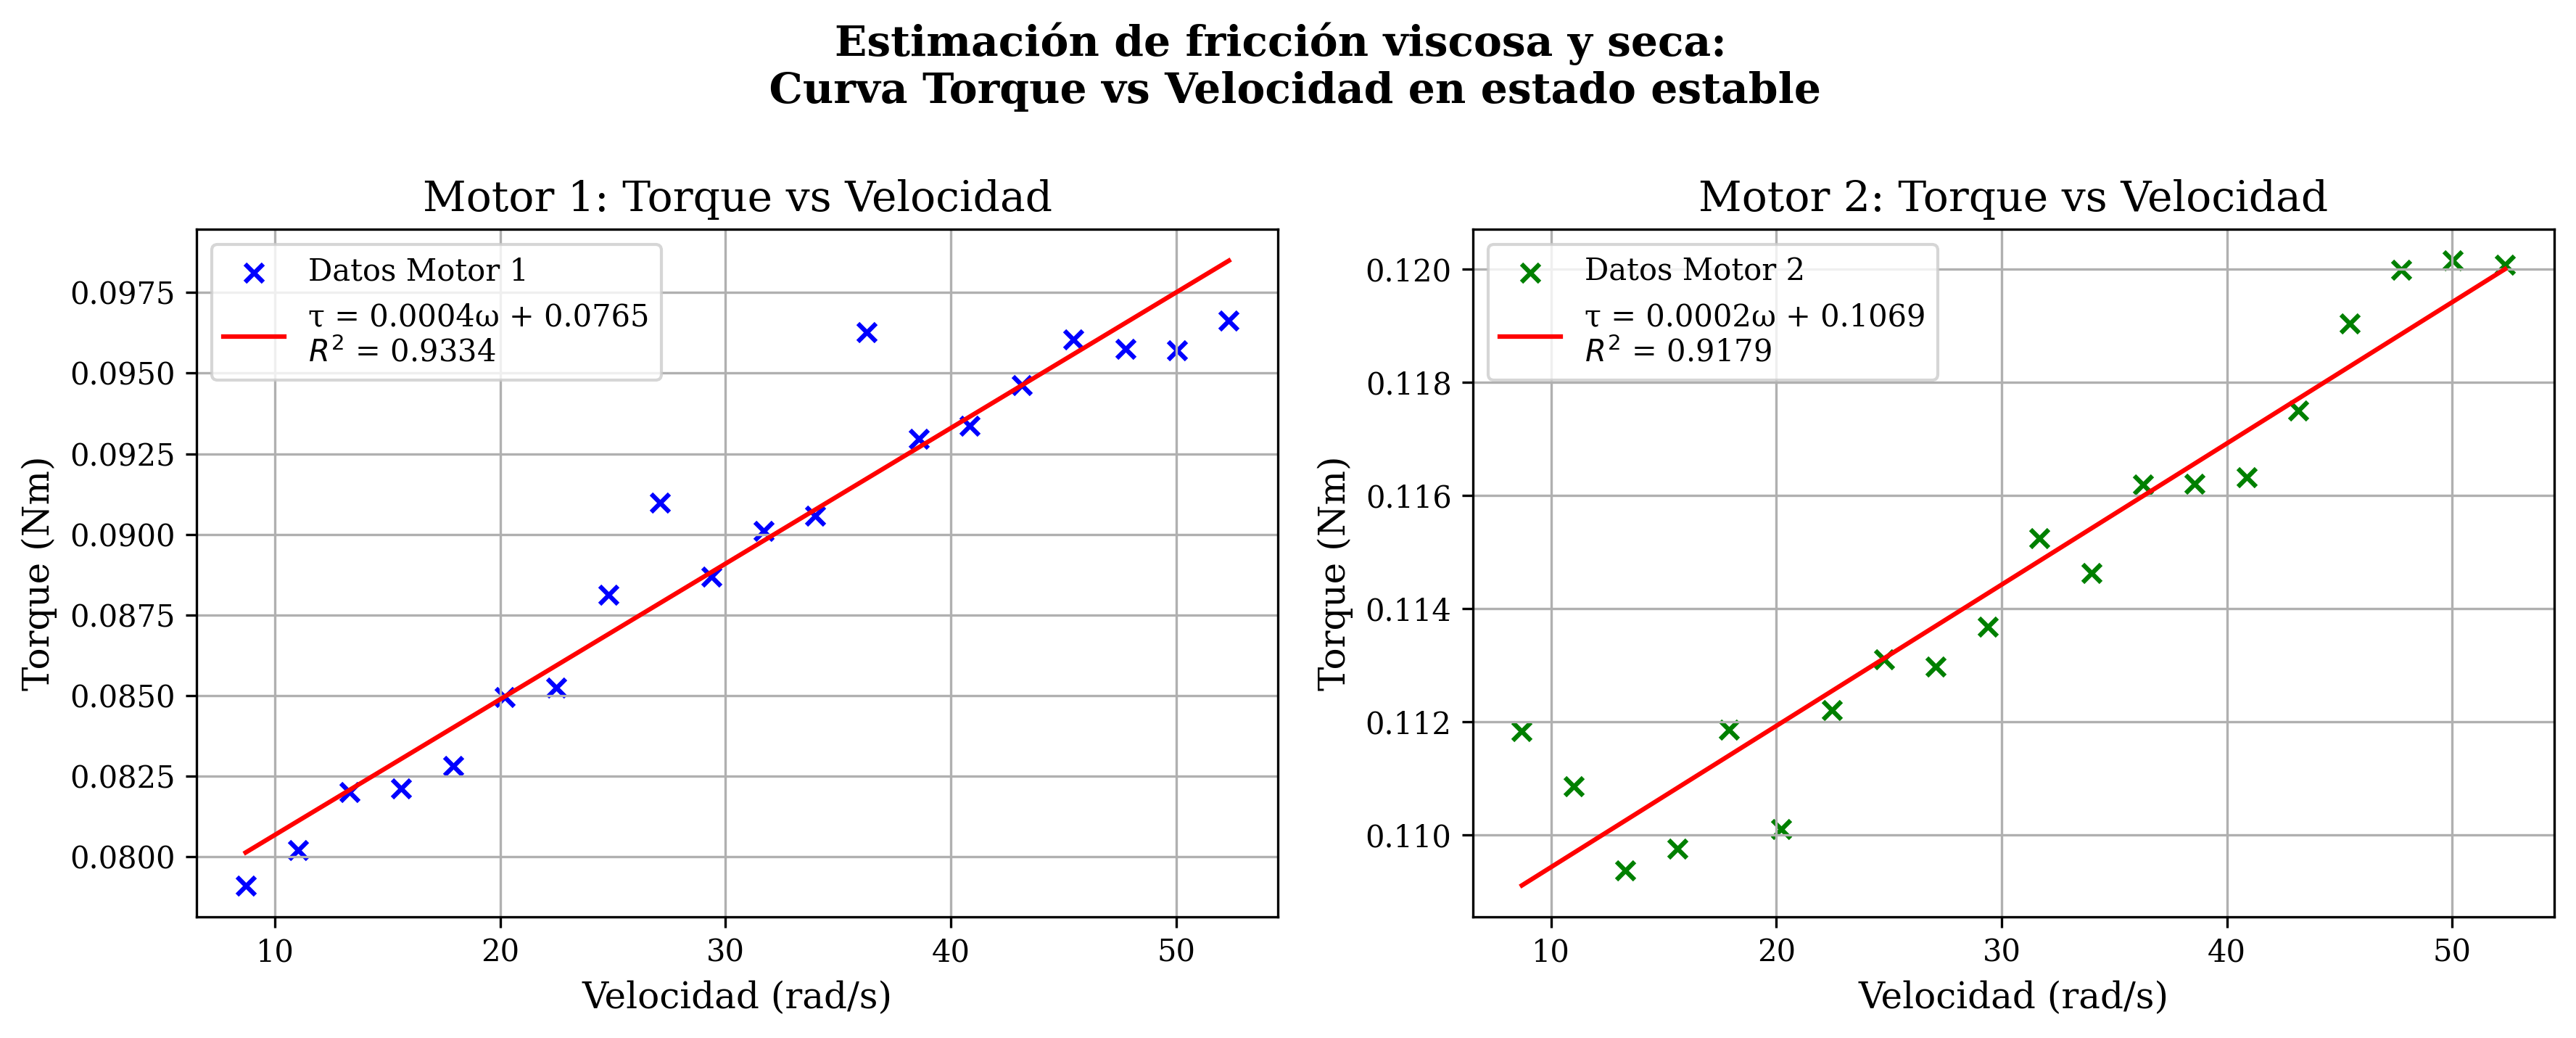

Motor 1: τ = (0.000421 ± 0.000026) * ω + (0.076466 ± 0.000882) Nm
Motor 2: τ = (0.000249 ± 0.000018) * ω + (0.106939 ± 0.000585) Nm


In [7]:
# --- Convert speeds to rad/s ---
df_steadystate['speed1_rad'] = df_steadystate['speed1'] * np.pi / 180
df_steadystate['speed2_rad'] = df_steadystate['speed2'] * np.pi / 180

# --- Group by speed_trial (mean only) ---
df_avg = df_steadystate.groupby('speed_trial').agg({
    'speed1_rad': 'mean',
    'speed2_rad': 'mean',
    'torque1': 'mean',
    'torque2': 'mean'
}).reset_index()

# --- Linear Fit (Torque = b * omega + offset) ---
reg1 = linregress(df_avg['speed1_rad'], df_avg['torque1'])
reg2 = linregress(df_avg['speed2_rad'], df_avg['torque2'])

# --- Compute R^2 values ---
r2_motor1 = reg1.rvalue ** 2
r2_motor2 = reg2.rvalue ** 2

# --- Plot Torque vs Speed ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Motor 1
axs[0].scatter(df_avg['speed1_rad'], df_avg['torque1'], color='blue', marker='x', label='Datos Motor 1')
axs[0].plot(df_avg['speed1_rad'], reg1.intercept + reg1.slope * df_avg['speed1_rad'], '-', color='red',
            label=f'τ = {reg1.slope:.4f}ω + {reg1.intercept:.4f}\n$R^2$ = {r2_motor1:.4f}')
axs[0].set_title('Motor 1: Torque vs Velocidad')
axs[0].set_xlabel('Velocidad (rad/s)')
axs[0].set_ylabel('Torque (Nm)')
axs[0].grid(True)
axs[0].legend()

# Motor 2
axs[1].scatter(df_avg['speed2_rad'], df_avg['torque2'], color='green', marker='x', label='Datos Motor 2')
axs[1].plot(df_avg['speed2_rad'], reg2.intercept + reg2.slope * df_avg['speed2_rad'], '-', color='red',
            label=f'τ = {reg2.slope:.4f}ω + {reg2.intercept:.4f}\n$R^2$ = {r2_motor2:.4f}')
axs[1].set_title('Motor 2: Torque vs Velocidad')
axs[1].set_xlabel('Velocidad (rad/s)')
axs[1].set_ylabel('Torque (Nm)')
axs[1].grid(True)
axs[1].legend()

fig.suptitle('Estimación de fricción viscosa y seca: \n Curva Torque vs Velocidad en estado estable', fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

# --- Print slopes & uncertainties ---
print(f"Motor 1: τ = ({reg1.slope:.6f} ± {reg1.stderr:.6f}) * ω + ({reg1.intercept:.6f} ± {reg1.intercept_stderr:.6f}) Nm")
print(f"Motor 2: τ = ({reg2.slope:.6f} ± {reg2.stderr:.6f}) * ω + ({reg2.intercept:.6f} ± {reg2.intercept_stderr:.6f}) Nm")

In [8]:
df_steadystate.to_csv(os.path.join(data_folder, 'steady_state_experiment.csv'), index=False)

In [36]:
trial_torques=[0.2,0.25,0.30,0.35,0.4,0.45,0.5]
num_trials=5
data_log = []
robot.set_control_mode("torque")
for trial_torque in trial_torques:
    for trial in range(num_trials):
        
        robot.set_target(trial_torque,trial_torque)
        time.sleep(0.02)
        t_0=time.time()
        while max(robot.get_motors_data()["speed"])<3000:
            motor_data=robot.get_motors_data()
            data_log.append({
                'time': time.time()-t_0,
                'series_id': trial,
                'torque_trial': trial_torque,
                'speed1': motor_data["speed"][0],
                'speed2': motor_data["speed"][1],
                'torque1': motor_data["torque"][0],
                'torque2': motor_data["torque"][1],
            })
            time.sleep(0.01)
        robot.set_target(0,0)
        time.sleep(2)
df_trial = pd.DataFrame(data_log)

Control Mode set to 'torque'. Setting targets to [0, 0]



In [37]:
df_trial.to_csv(os.path.join(data_folder, 'rotor_experiment.csv'), index=False)

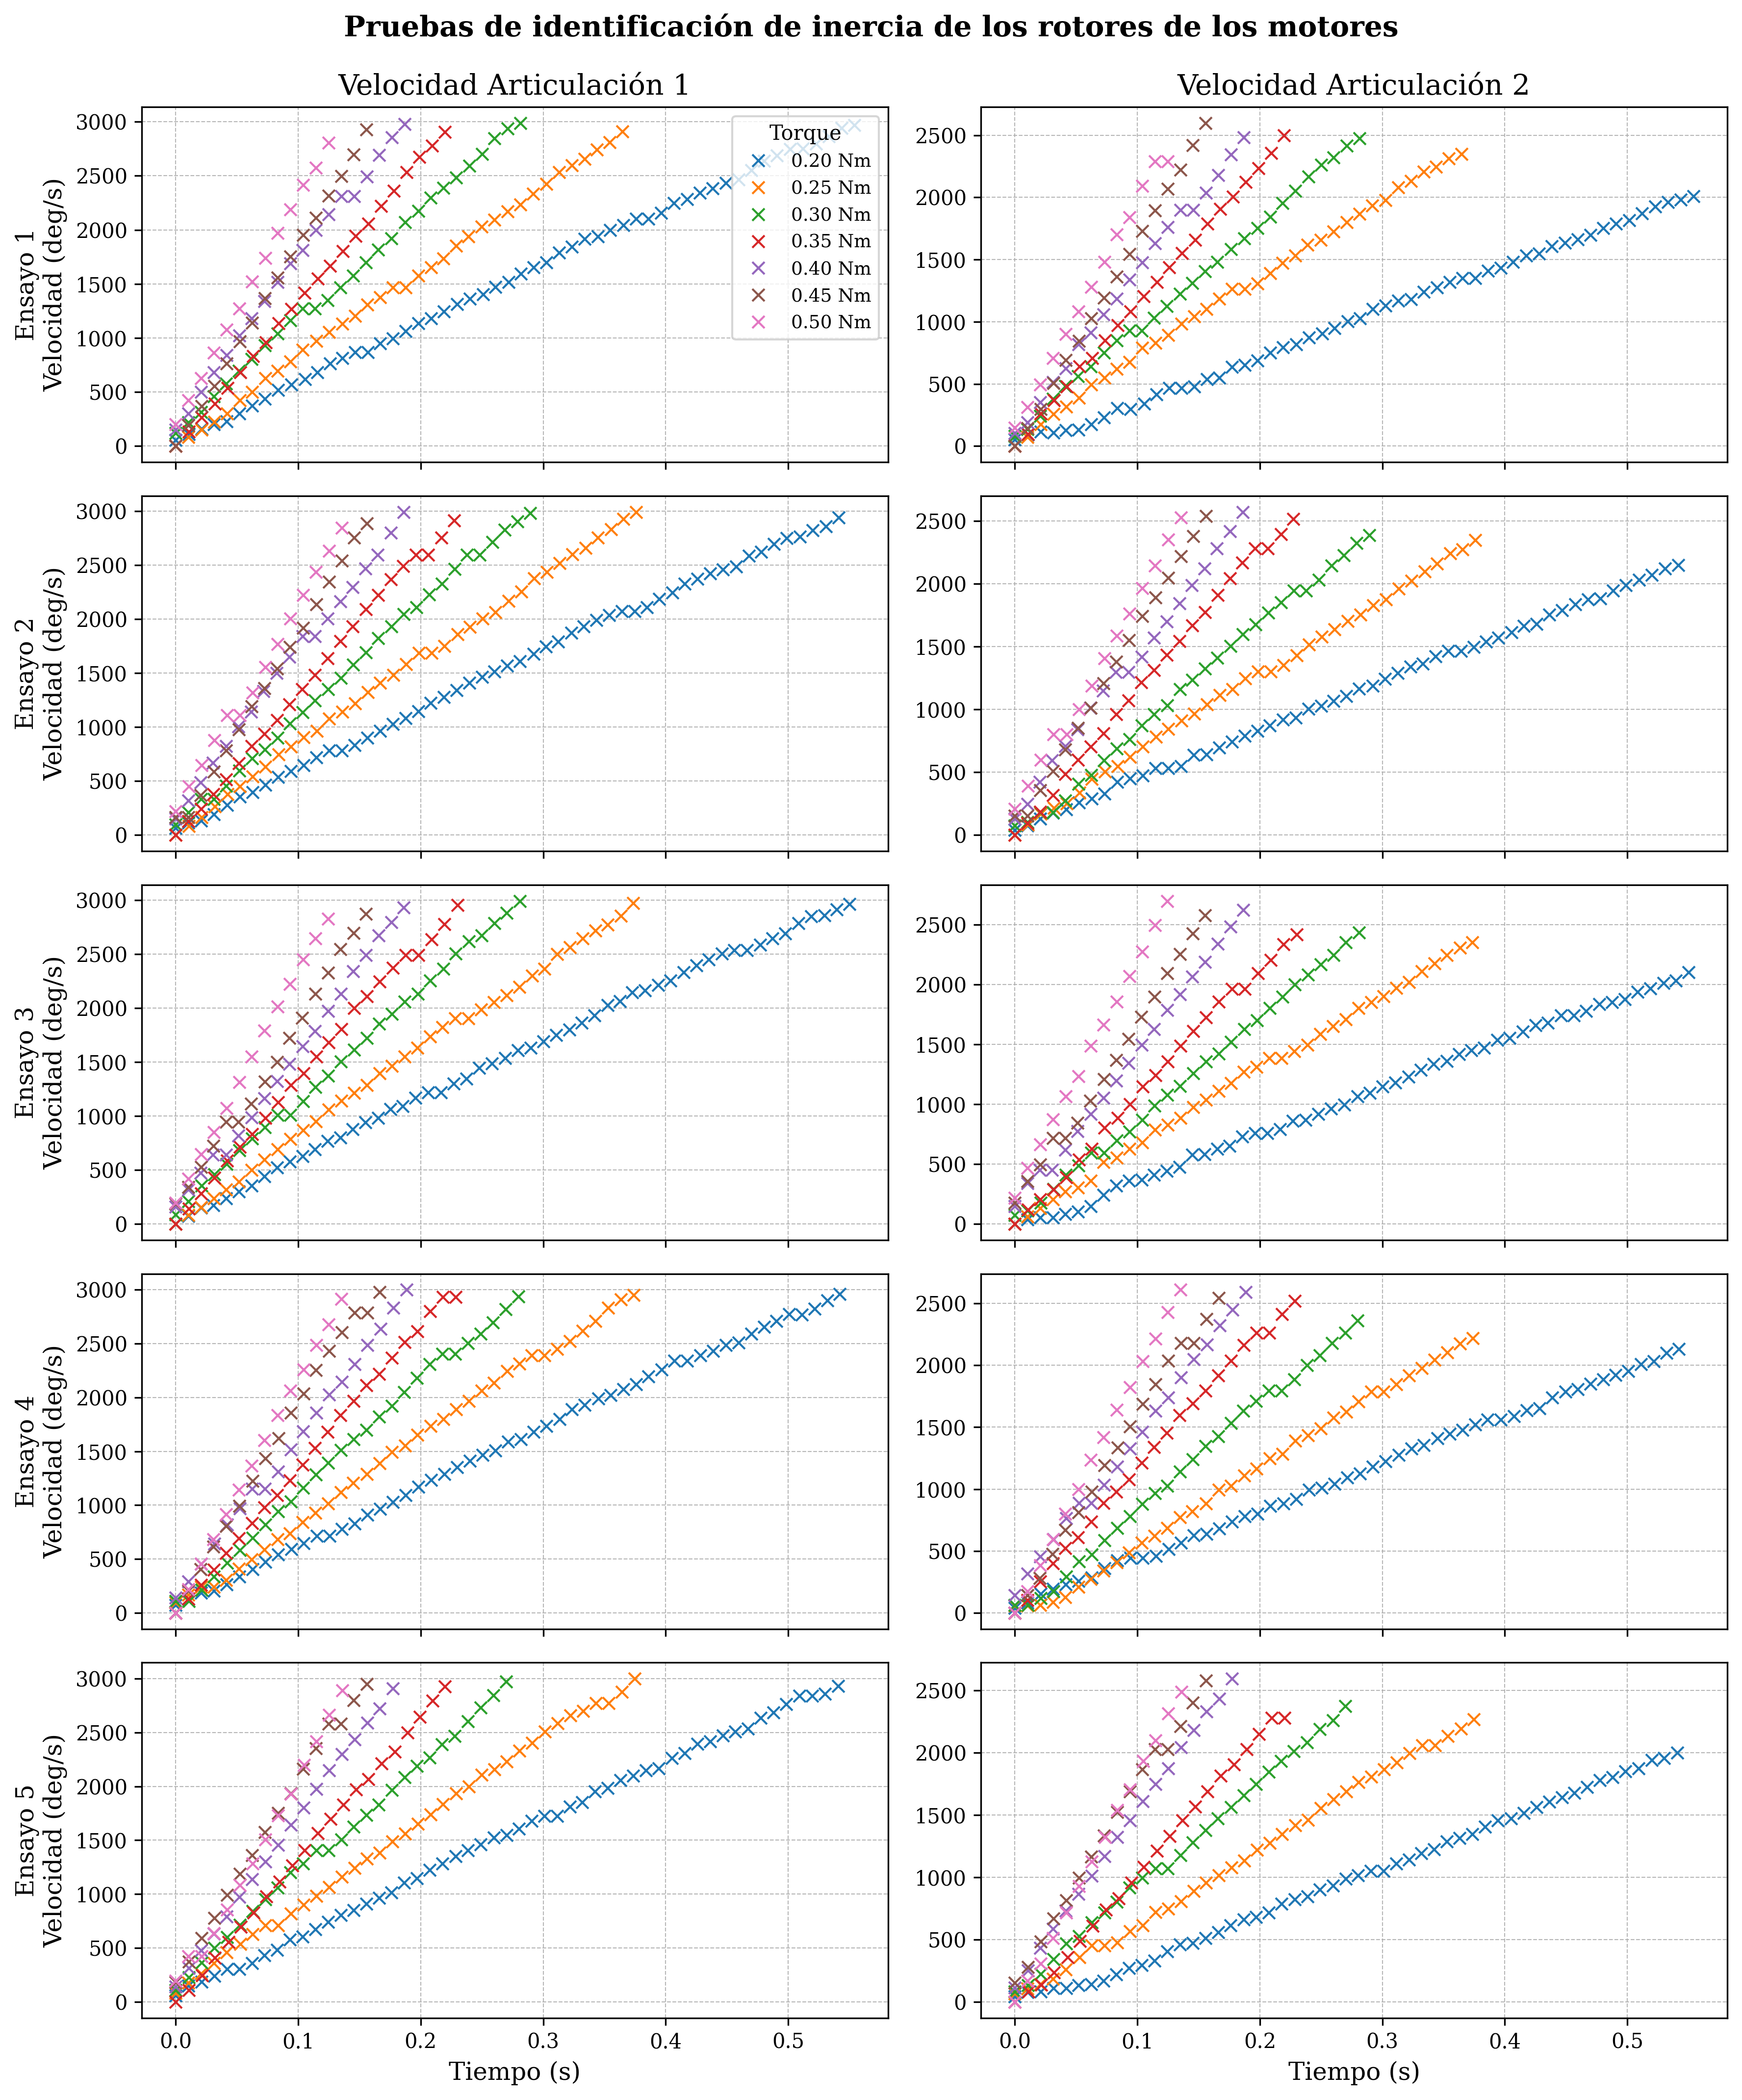

In [38]:
# Obtener series_id únicos (ensayos)
unique_series = np.sort(df_trial['series_id'].unique())
n_series = len(unique_series)

# Obtener torque_trials únicos (para leyenda)
unique_torques = np.sort(df_trial['torque_trial'].unique())

# Crear figura: n_series filas, 2 columnas (speed1, speed2)
fig, axes = plt.subplots(n_series, 2, figsize=(12, 3 * n_series), sharex='col')

# Garantizar que axes sea 2D incluso si n_series = 1
if n_series == 1:
    axes = axes.reshape(1, 2)

# --- Gráficas por serie ---
for i, series_id in enumerate(unique_series):
    trial_data = df_trial[df_trial['series_id'] == series_id]
    
    for torque in unique_torques:
        torque_data = trial_data[trial_data['torque_trial'] == torque]
        
        # Speed1 (columna izquierda)
        axes[i, 0].plot(torque_data['time'], torque_data['speed1'], 'x', label=f'{torque:.2f} Nm')
        # Speed2 (columna derecha)
        axes[i, 1].plot(torque_data['time'], torque_data['speed2'], 'x', label=f'{torque:.2f} Nm')

    # Etiquetas de eje Y por serie
    axes[i, 0].set_ylabel(f'Ensayo {series_id+1}\nVelocidad (deg/s)')

    # Grillas
    axes[i, 0].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)
    axes[i, 1].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)

# Etiqueta de tiempo solo en la última fila
axes[-1, 0].set_xlabel('Tiempo (s)')
axes[-1, 1].set_xlabel('Tiempo (s)')

# Títulos de columnas
axes[0, 0].set_title('Velocidad Articulación 1')
axes[0, 1].set_title('Velocidad Articulación 2')

# Leyenda en la primera gráfica (afuera si caben)
axes[0, 0].legend(title='Torque', fontsize=9, title_fontsize=10, loc='upper right')

# Título general
fig.suptitle('Pruebas de identificación de inercia de los rotores de los motores', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

In [39]:
# Known friction model intercepts and their uncertainties
tf_motor1 = 0.076466 
tf_motor1_uncertainty = 0.000882

tf_motor2 = 0.106939
tf_motor2_uncertainty =  0.000585

torque_uncertainty = 0.01  # Adjust if you know it

deg_to_rad = np.pi / 180

results = []

for series_id in df_trial['series_id'].unique():
    for torque in df_trial['torque_trial'].unique():
        data = df_trial[(df_trial['series_id'] == series_id) & (df_trial['torque_trial'] == torque)]
        if len(data) < 2:
            continue
        
        # Regression for speed1
        reg1 = linregress(data['time'], data['speed1'])
        # Regression for speed2
        reg2 = linregress(data['time'], data['speed2'])

        # Compute inertia with friction correction
        corrected_torque1 = torque - tf_motor1
        corrected_torque2 = torque - tf_motor2

        inertia1 = (corrected_torque1 * 180) / (reg1.slope * np.pi) if reg1.slope != 0 else np.nan
        inertia2 = (corrected_torque2 * 180) / (reg2.slope * np.pi) if reg2.slope != 0 else np.nan

        # Propagate uncertainties:
        # δI = I * sqrt( (δτ / (τ - tf))^2 + (δtf / (τ - tf))^2 + (δslope / slope)^2 )

        inertia1_stderr = np.abs(inertia1) * np.sqrt(
            (torque_uncertainty / corrected_torque1) ** 2 +
            (tf_motor1_uncertainty / corrected_torque1) ** 2 +
            (reg1.stderr / reg1.slope) ** 2
        ) if reg1.slope != 0 else np.nan

        inertia2_stderr = np.abs(inertia2) * np.sqrt(
            (torque_uncertainty / corrected_torque2) ** 2 +
            (tf_motor2_uncertainty / corrected_torque2) ** 2 +
            (reg2.stderr / reg2.slope) ** 2
        ) if reg2.slope != 0 else np.nan

        # Store results
        results.append({
            'series_id': series_id,
            'torque_trial': torque,
            'speed1_slope': reg1.slope,
            'speed1_intercept': reg1.intercept,
            'speed1_slope_stderr': reg1.stderr,
            'speed1_intercept_stderr': reg1.intercept_stderr,
            'speed2_slope': reg2.slope,
            'speed2_intercept': reg2.intercept,
            'speed2_slope_stderr': reg2.stderr,
            'speed2_intercept_stderr': reg2.intercept_stderr,
            'inertia1': inertia1,
            'inertia1_stderr': inertia1_stderr,
            'inertia2': inertia2,
            'inertia2_stderr': inertia2_stderr
        })

# Convert to DataFrame
df_results = pd.DataFrame(results)


In [40]:
df_results.to_csv(os.path.join(data_folder, 'rotor_results.csv'), index=False)

In [41]:
format_sigfig = lambda x: f"{x:.2g}"
df_formatted = df_results.applymap(format_sigfig)
latex_table = df_formatted.to_latex(index=False, caption="Experimental Results", label="tab:results")
print(latex_table)


\begin{table}
\caption{Experimental Results}
\label{tab:results}
\begin{tabular}{llllllllllllll}
\toprule
series_id & torque_trial & speed1_slope & speed1_intercept & speed1_slope_stderr & speed1_intercept_stderr & speed2_slope & speed2_intercept & speed2_slope_stderr & speed2_intercept_stderr & inertia1 & inertia1_stderr & inertia2 & inertia2_stderr \\
\midrule
0 & 0.2 & 5.3e+03 & 67 & 24 & 7.9 & 3.7e+03 & -15 & 22 & 7.1 & 0.0013 & 0.00011 & 0.0014 & 0.00016 \\
0 & 0.25 & 8e+03 & 18 & 42 & 9 & 6.4e+03 & 72 & 48 & 10 & 0.0012 & 7.3e-05 & 0.0013 & 9e-05 \\
0 & 0.3 & 1e+04 & 1.4e+02 & 83 & 14 & 8.5e+03 & 93 & 64 & 11 & 0.0013 & 5.7e-05 & 0.0013 & 6.8e-05 \\
0 & 0.35 & 1.3e+04 & -14 & 59 & 7.6 & 1.1e+04 & 11 & 49 & 6.3 & 0.0012 & 4.3e-05 & 0.0012 & 5.1e-05 \\
0 & 0.4 & 1.5e+04 & 2.2e+02 & 2.1e+02 & 23 & 1.3e+04 & 1.2e+02 & 1.8e+02 & 19 & 0.0012 & 4.2e-05 & 0.0013 & 4.9e-05 \\
0 & 0.45 & 1.9e+04 & -13 & 87 & 8 & 1.7e+04 & -26 & 76 & 6.9 & 0.0011 & 3.1e-05 & 0.0012 & 3.5e-05 \\
0 & 0.5 & 2.

C:\Users\juanp\AppData\Local\Temp\ipykernel_22816\2904712049.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatted = df_results.applymap(format_sigfig)


In [43]:
# Remove NaNs to avoid errors in calculation
valid_inertia1 = df_results[~df_results['inertia1'].isna()]
valid_inertia2 = df_results[~df_results['inertia2'].isna()]

# Number of valid samples
n1 = len(valid_inertia1)
n2 = len(valid_inertia2)

# Compute averages
inertia1_avg = valid_inertia1['inertia1'].mean()
inertia2_avg = valid_inertia2['inertia2'].mean()

# Propagate uncertainties (sqrt of sum of variances / n^2)
inertia1_std_error = np.sqrt(np.sum(valid_inertia1['inertia1_stderr']**2)) / n1
inertia2_std_error = np.sqrt(np.sum(valid_inertia2['inertia2_stderr']**2)) / n2

# Report results
print(f"Inertia1 average = {inertia1_avg:.6f} ± {inertia1_std_error:.6f} kg·m²")
print(f"Inertia2 average = {inertia2_avg:.6f} ± {inertia2_std_error:.6f} kg·m²")


Inertia1 average = 0.001227 ± 0.000010 kg·m²
Inertia2 average = 0.001287 ± 0.000013 kg·m²


In [44]:
trial_torques=[0.2,0.25,0.30,0.35,0.4,0.45,0.5]
num_trials=5
data_log = []

for trial_torque in trial_torques:
    for trial in range(num_trials):
        
        robot.set_target(trial_torque,trial_torque)
        time.sleep(0.02)
        t_0=time.time()
        while max(robot.get_motors_data()["speed"])<3000:
            motor_data=robot.get_motors_data()
            data_log.append({
                'time': time.time()-t_0,
                'series_id': trial,
                'torque_trial': trial_torque,
                'speed2': motor_data["speed"][1],
                'torque2': motor_data["torque"][1],
            })
            time.sleep(0.01)
        robot.set_target(0,0)
        time.sleep(2)
df_trial = pd.DataFrame(data_log)

In [45]:
df_trial.to_csv(os.path.join(data_folder, 'proximal_experiment.csv'), index=False)

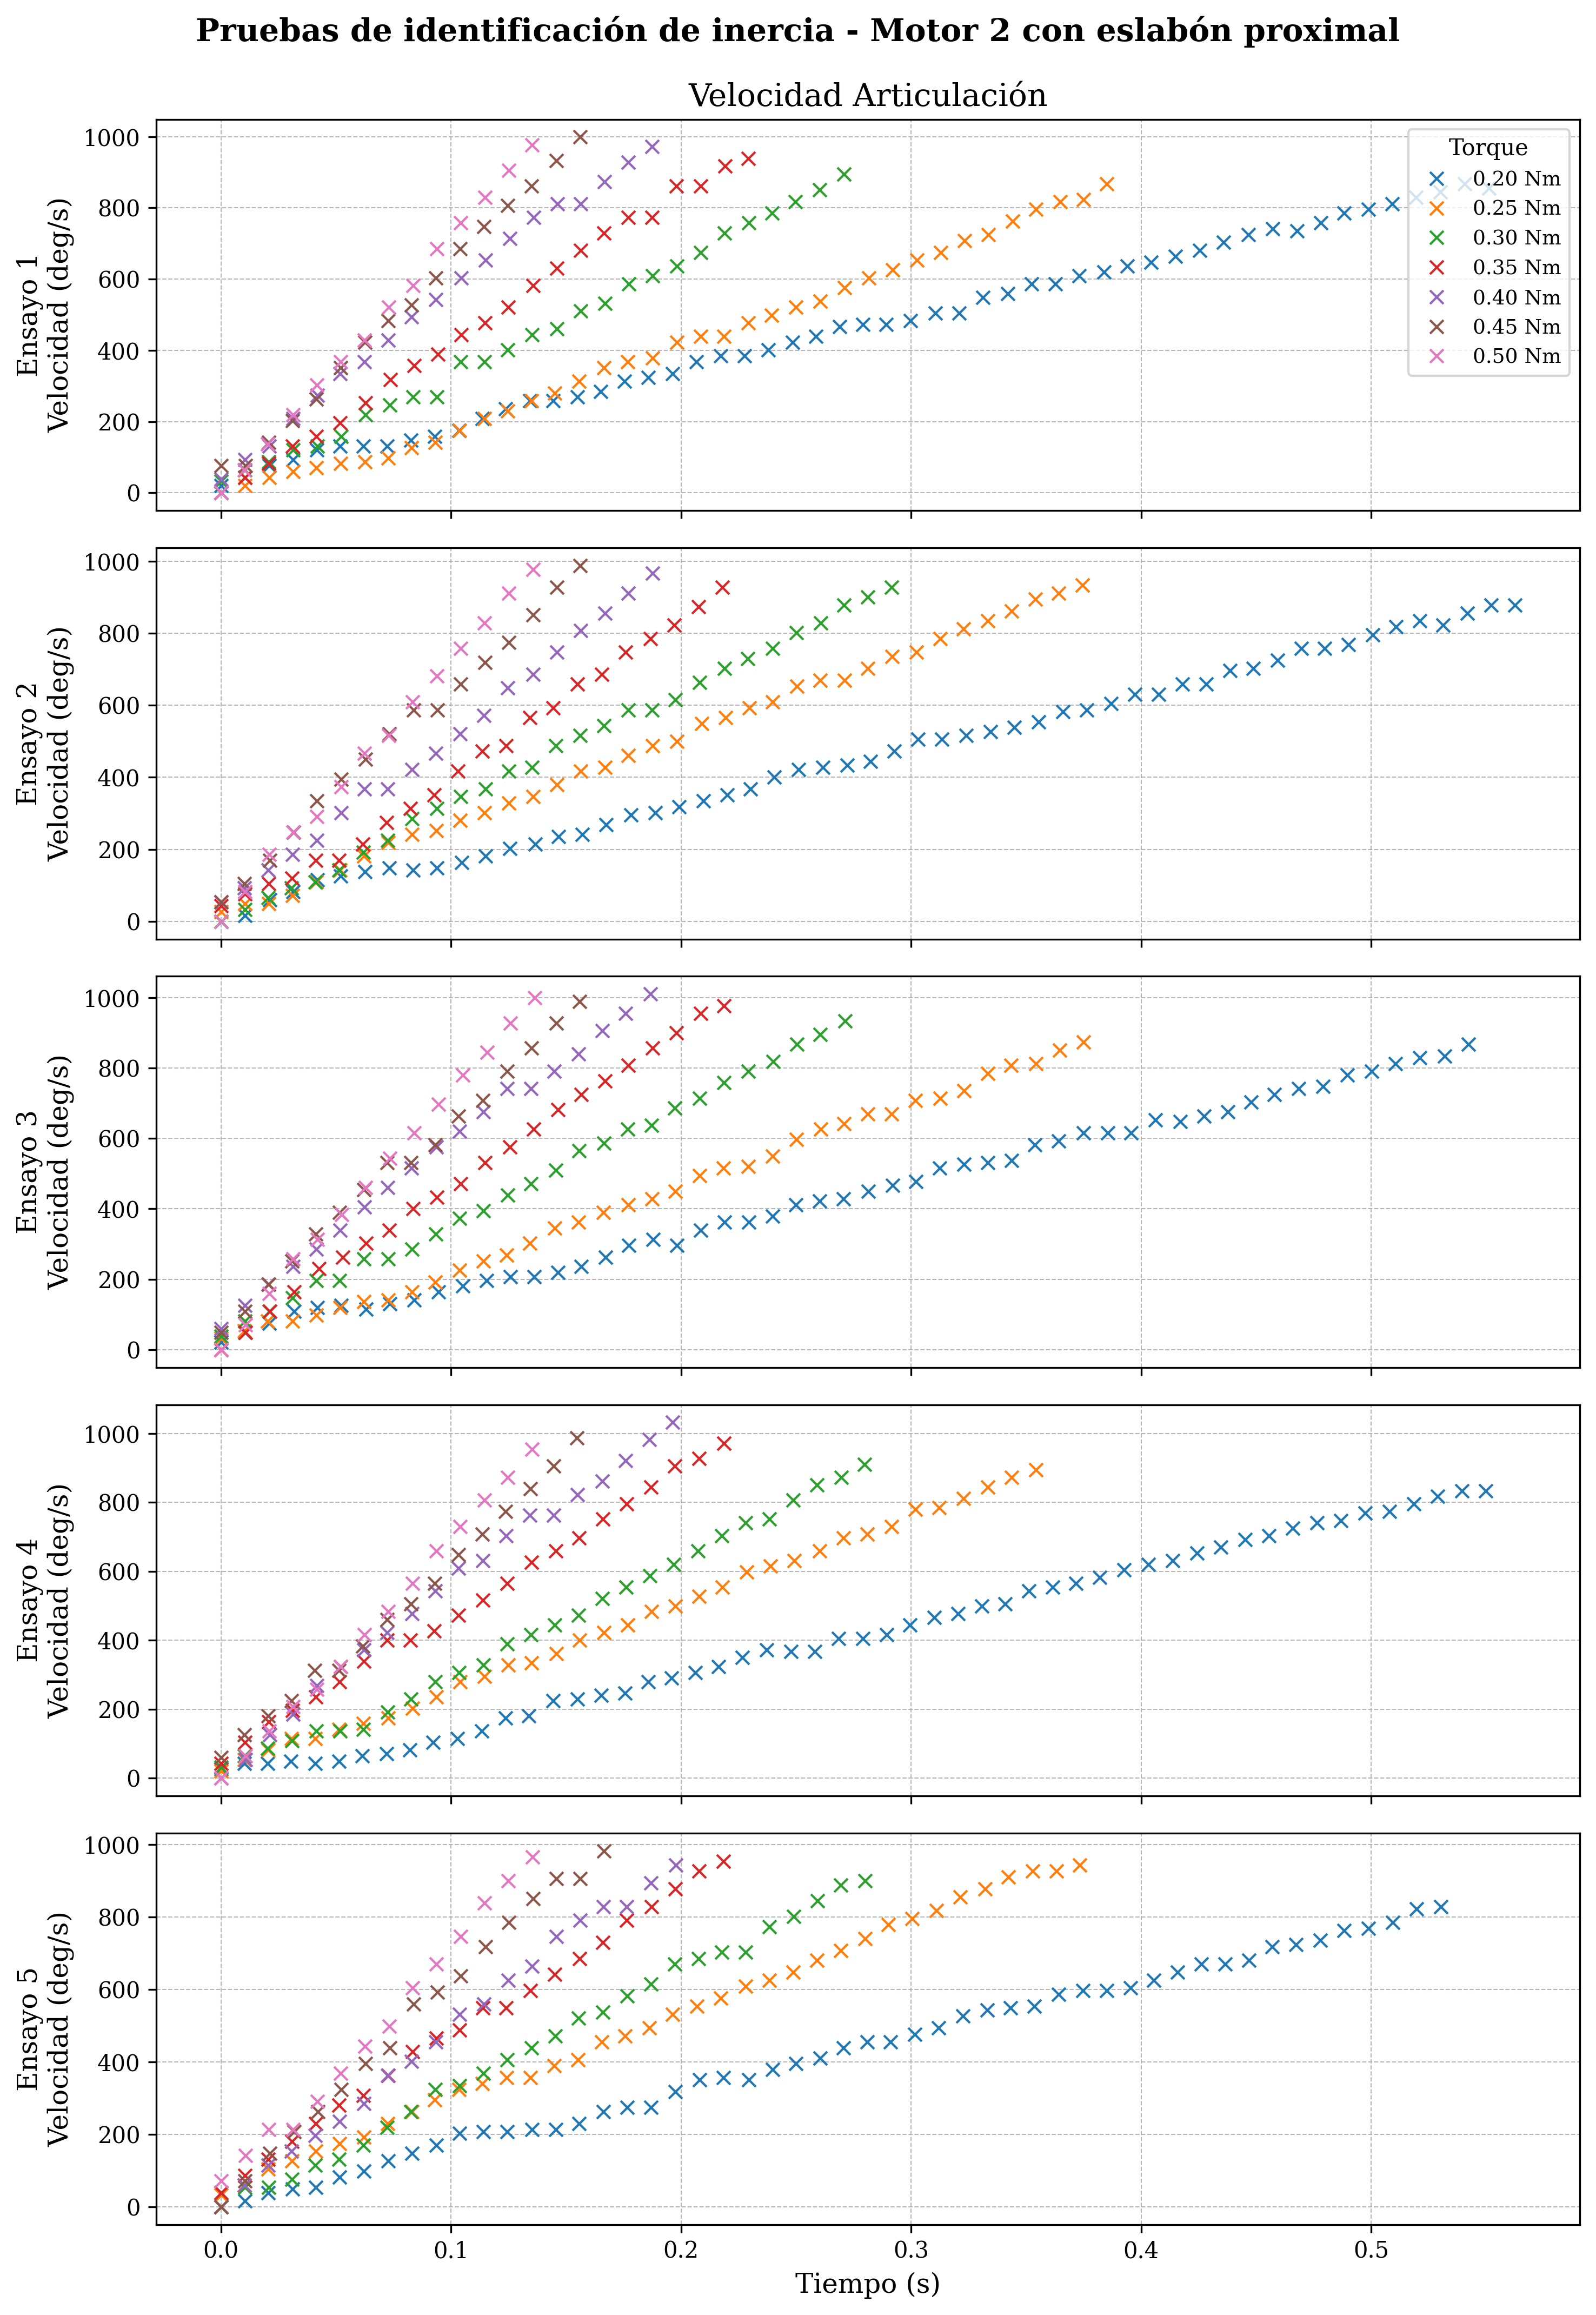

In [46]:
# Unique series_id (trial numbers)
unique_series = np.sort(df_trial['series_id'].unique())
n_series = len(unique_series)

# Unique torque_trial values for legend
unique_torques = np.sort(df_trial['torque_trial'].unique())

# Create subplot grid: n_series rows, 1 column
fig, axes = plt.subplots(n_series, 1, figsize=(10, 3 * n_series), sharex=True)

# Ensure axes is always iterable
if n_series == 1:
    axes = [axes]

# Plotting loop
for i, series_id in enumerate(unique_series):
    trial_data = df_trial[df_trial['series_id'] == series_id]
    
    # Plot each torque_trial for this series
    for torque in unique_torques:
        torque_data = trial_data[trial_data['torque_trial'] == torque]
        
        axes[i].plot(torque_data['time'], torque_data['speed2'], 'x', label=f'{torque:.2f} Nm')
    
    # Y-axis label per row
    axes[i].set_ylabel(f'Ensayo {series_id+1}\nVelocidad (deg/s)')

    # Grid formatting
    axes[i].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)

# X-axis label only on bottom plot
axes[-1].set_xlabel('Tiempo (s)')

# Title for top plot
axes[0].set_title('Velocidad Articulación')

# Legend in first plot only
axes[0].legend(title='Torque', fontsize=9, title_fontsize=10, loc='upper right')

# Global Figure Title
fig.suptitle('Pruebas de identificación de inercia - Motor 2 con eslabón proximal', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

In [47]:
torque_uncertainty = 0  # Ajusta si aplica

# Friction model intercept for motor 2
tf_motor2 = 0.106939 
tf_motor2_uncertainty = 0.000585

deg_to_rad = np.pi / 180  # Conversion grados a radianes

# Lista para almacenar resultados
results = []

# Iterar sobre series_id (ensayos)
for series_id in df_trial['series_id'].unique():
    # Iterar sobre torque_trial
    for torque in df_trial['torque_trial'].unique():
        # Filtrar datos para esta combinación de ensayo y torque
        data = df_trial[(df_trial['series_id'] == series_id) & (df_trial['torque_trial'] == torque)]
        
        if len(data) < 2:
            continue  # No se puede hacer regresión con menos de 2 puntos
        
        # Regresión lineal speed2 vs time
        reg2 = linregress(data['time'], data['speed2'])

        # Calcular torque corregido con la fricción
        corrected_torque = torque - tf_motor2

        # Cálculo de inercia (conversión de deg/s² a rad/s²)
        inertia2 = (corrected_torque * 180) / (reg2.slope * np.pi) if reg2.slope != 0 else np.nan

        # Propagación de incertidumbre en la inercia:
        # δI = I * sqrt( (δτ / (τ - tf))^2 + (δtf / (τ - tf))^2 + (δslope / slope)^2 )
        inertia2_stderr = np.abs(inertia2) * np.sqrt(
            (torque_uncertainty / corrected_torque) ** 2 +
            (tf_motor2_uncertainty / corrected_torque) ** 2 +
            (reg2.stderr / reg2.slope) ** 2
        ) if reg2.slope != 0 else np.nan

        # Guardar resultados
        results.append({
            'series_id': series_id,
            'torque_trial': torque,
            'speed2_slope': reg2.slope,
            'speed2_intercept': reg2.intercept,
            'speed2_slope_stderr': reg2.stderr,
            'speed2_intercept_stderr': reg2.intercept_stderr,
            'inertia2': inertia2,
            'inertia2_stderr': inertia2_stderr
        })

# Convertir a DataFrame
df_results = pd.DataFrame(results)

In [48]:
df_results.to_csv(os.path.join(data_folder, 'proximal_results.csv'), index=False)

In [49]:
format_sigfig = lambda x: f"{x:.2g}"
df_formatted = df_results.applymap(format_sigfig)
latex_table = df_formatted.to_latex(index=False, caption="Experimental Results", label="tab:results")
print(latex_table)

\begin{table}
\caption{Experimental Results}
\label{tab:results}
\begin{tabular}{llllllll}
\toprule
series_id & torque_trial & speed2_slope & speed2_intercept & speed2_slope_stderr & speed2_intercept_stderr & inertia2 & inertia2_stderr \\
\midrule
0 & 0.2 & 1.5e+03 & 38 & 8.8 & 2.8 & 0.0035 & 3e-05 \\
0 & 0.25 & 2.3e+03 & -40 & 27 & 5.9 & 0.0036 & 4.4e-05 \\
0 & 0.3 & 3.2e+03 & 9.3 & 36 & 5.7 & 0.0034 & 4e-05 \\
0 & 0.35 & 4.3e+03 & -4.2 & 48 & 6.5 & 0.0033 & 3.8e-05 \\
0 & 0.4 & 5e+03 & 56 & 88 & 9.7 & 0.0033 & 5.9e-05 \\
0 & 0.45 & 6.2e+03 & 26 & 91 & 8.4 & 0.0032 & 4.7e-05 \\
0 & 0.5 & 7.3e+03 & -9 & 57 & 4.5 & 0.0031 & 2.5e-05 \\
1 & 0.2 & 1.5e+03 & 18 & 10 & 3.4 & 0.0035 & 3.2e-05 \\
1 & 0.25 & 2.5e+03 & 21 & 16 & 3.5 & 0.0033 & 2.6e-05 \\
1 & 0.3 & 3.2e+03 & -0.88 & 26 & 4.4 & 0.0034 & 3e-05 \\
1 & 0.35 & 4.2e+03 & -6.6 & 78 & 9.8 & 0.0033 & 6.2e-05 \\
1 & 0.4 & 4.9e+03 & 35 & 66 & 7.2 & 0.0034 & 4.7e-05 \\
1 & 0.45 & 5.8e+03 & 65 & 1.1e+02 & 10 & 0.0034 & 6.5e-05 \\
1 & 0.5 & 7.

C:\Users\juanp\AppData\Local\Temp\ipykernel_22816\881678063.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatted = df_results.applymap(format_sigfig)


In [50]:
# Filtrar los valores válidos (sin NaN)
valid_inertia2 = df_results[~df_results['inertia2'].isna()]

# Número de muestras válidas
n = len(valid_inertia2)

# Promedio de inercia2
inertia2_avg = valid_inertia2['inertia2'].mean()

# Propagación de incertidumbre (errores independientes)
inertia2_std_error = np.sqrt(np.sum(valid_inertia2['inertia2_stderr']**2)) / n

# Mostrar resultado
print(f"Inercia promedio (Motor 2): {inertia2_avg:.6f} ± {inertia2_std_error:.6f} kg·m²")

Inercia promedio (Motor 2): 0.003344 ± 0.000008 kg·m²


In [51]:
# Valor conocido de inercia de Motor 2 (modelo)
inertia2_model = 0.001287   # kg·m²
inertia2_model_uncertainty = 0.000013  # kg·m²

# Diferencia
delta_inertia2 = inertia2_avg - inertia2_model

# Propagación de incertidumbre
delta_inertia2_uncertainty = np.sqrt(inertia2_std_error**2 + inertia2_model_uncertainty**2)

# Mostrar resultado
print(f"Diferencia de inercia: {delta_inertia2:.6f} ± {delta_inertia2_uncertainty:.6f} kg·m²")


Diferencia de inercia: 0.002057 ± 0.000015 kg·m²


In [52]:
trial_torques=[0.2,0.25,0.30,0.35,0.4,0.45,0.5]
num_trials=5
data_log = []

for trial_torque in trial_torques:
    for trial in range(num_trials):
        
        robot.set_target(trial_torque,trial_torque)
        time.sleep(0.02)
        t_0=time.time()
        while max(robot.get_motors_data()["speed"])<3000:
            motor_data=robot.get_motors_data()
            data_log.append({
                'time': time.time()-t_0,
                'series_id': trial,
                'torque_trial': trial_torque,
                'speed2': motor_data["speed"][1],
                'torque2': motor_data["torque"][1],
            })
            time.sleep(0.01)
        robot.set_target(0,0)
        time.sleep(2)
df_trial = pd.DataFrame(data_log)

In [53]:
df_trial.to_csv(os.path.join(data_folder, 'distal_experiment.csv'), index=False)

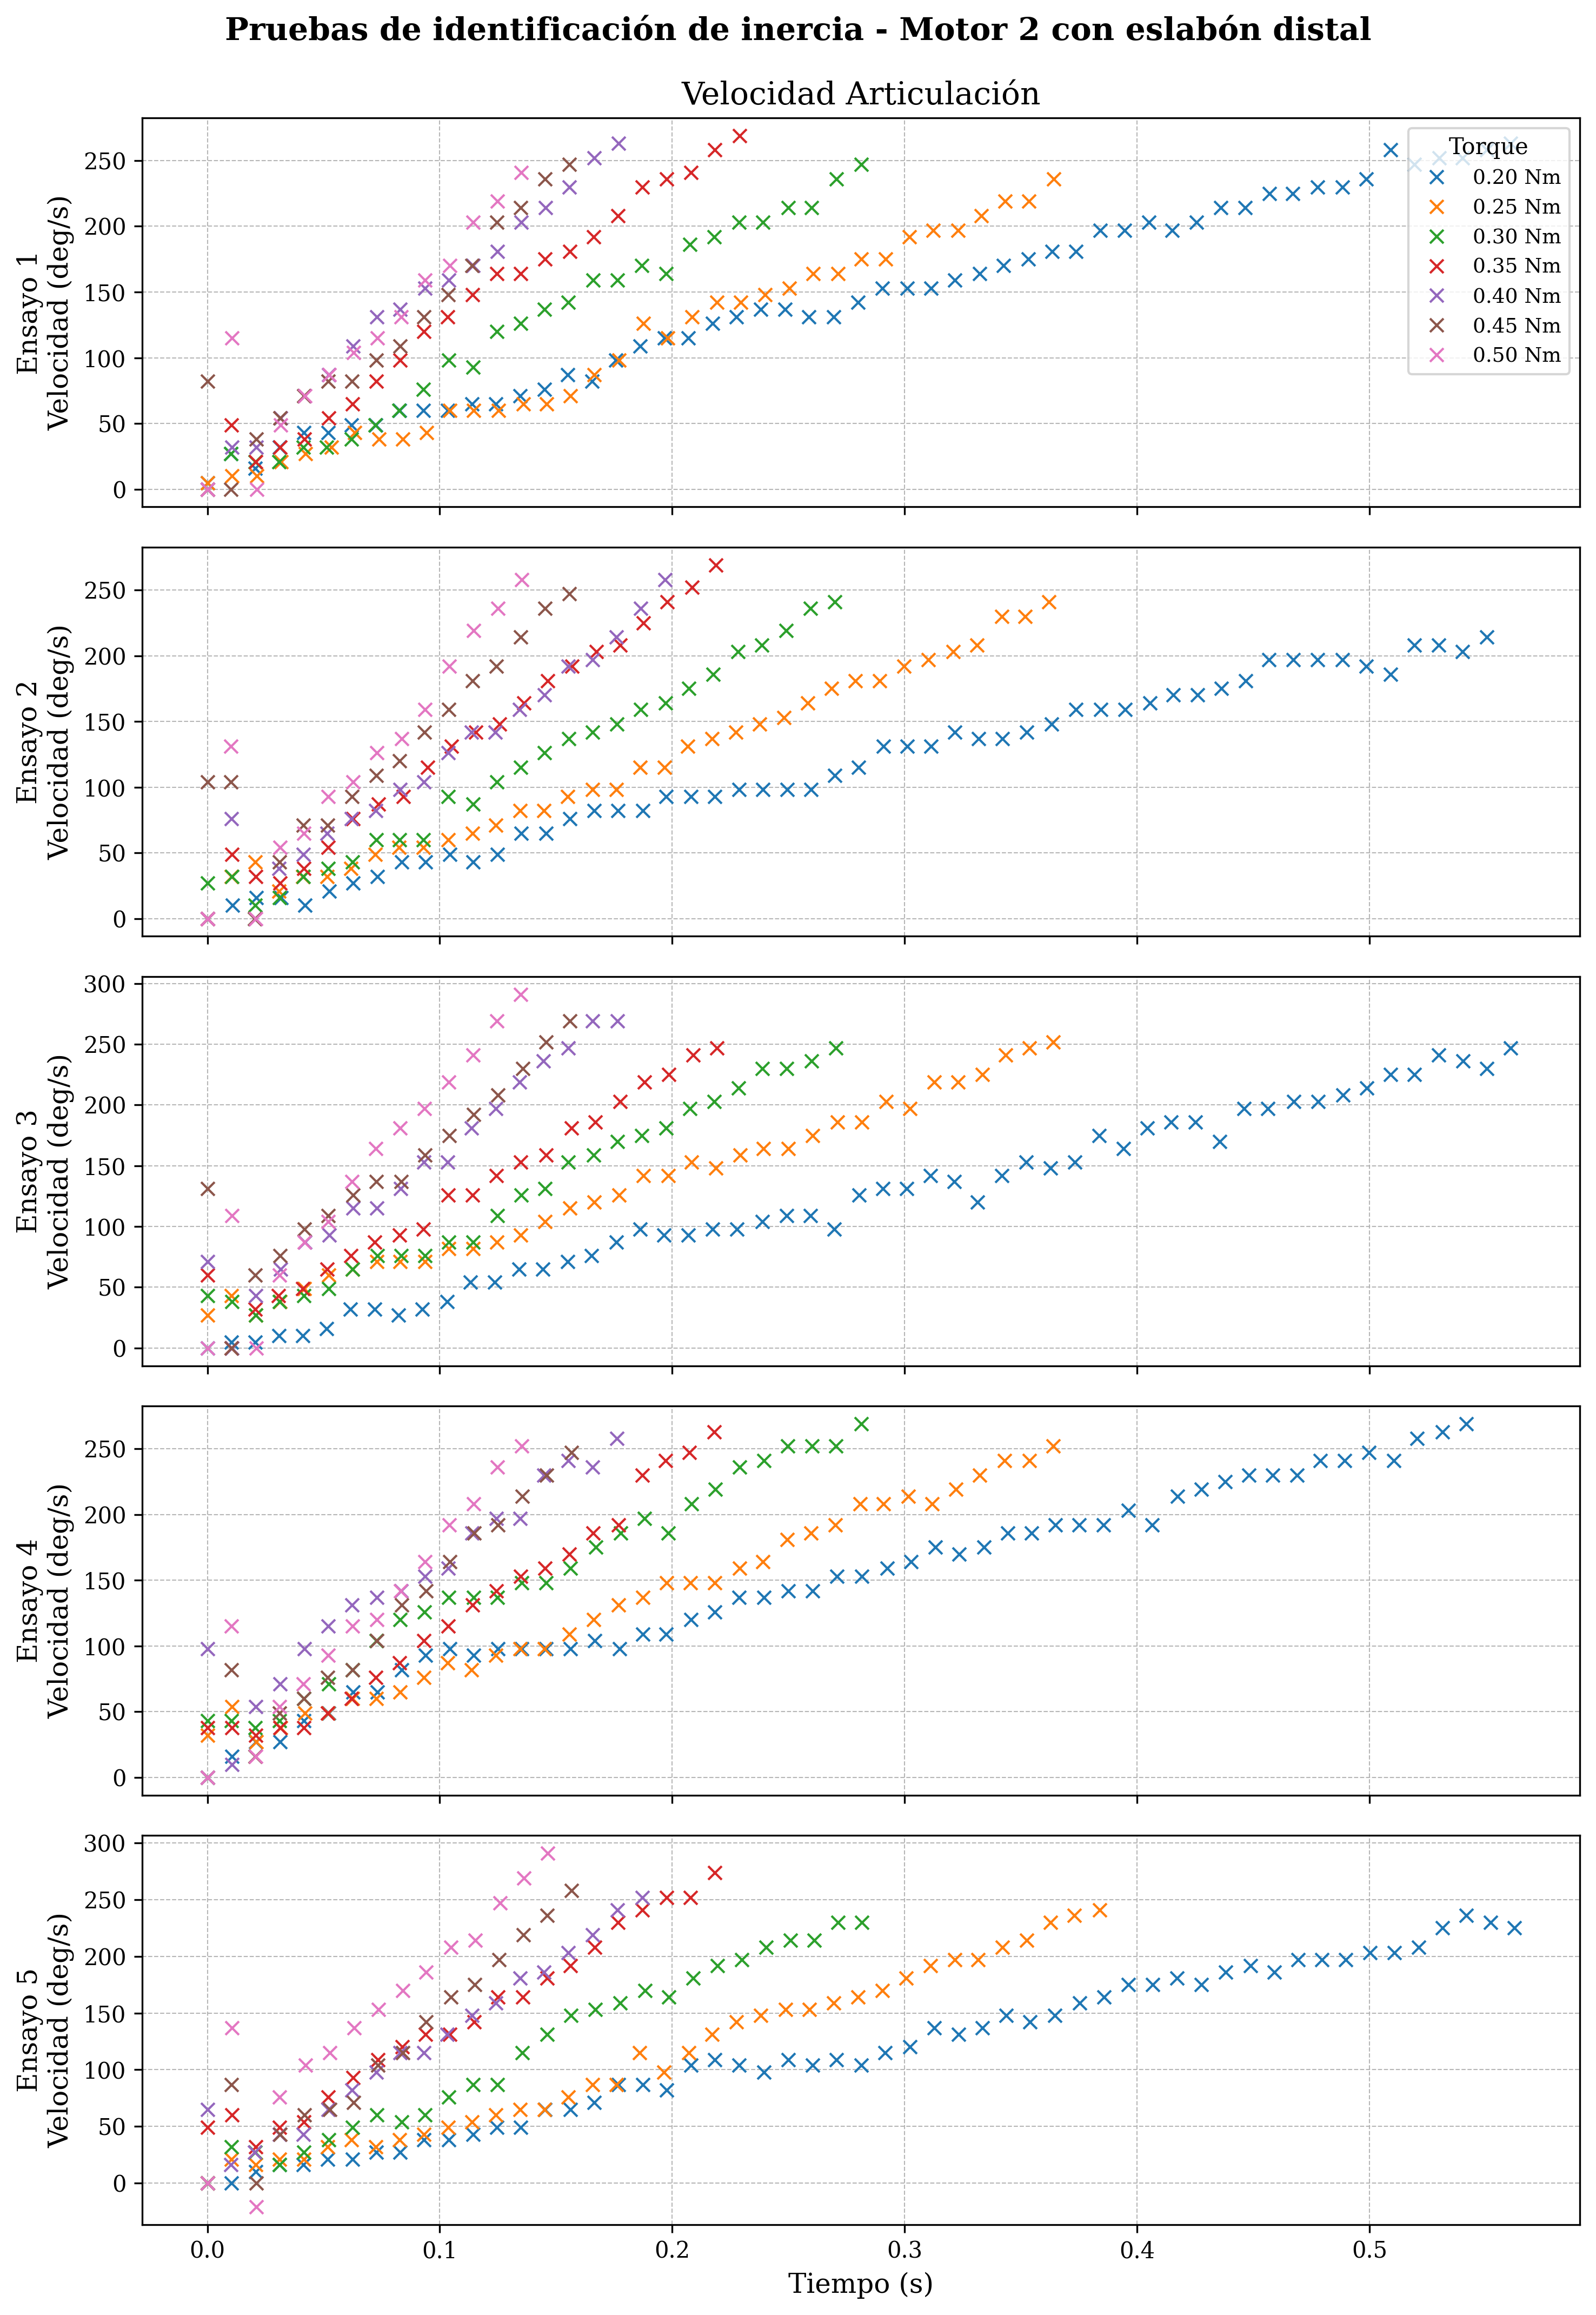

In [54]:
# Unique series_id (trial numbers)
unique_series = np.sort(df_trial['series_id'].unique())
n_series = len(unique_series)

# Unique torque_trial values for legend
unique_torques = np.sort(df_trial['torque_trial'].unique())

# Create subplot grid: n_series rows, 1 column
fig, axes = plt.subplots(n_series, 1, figsize=(10, 3 * n_series), sharex=True)

# Ensure axes is always iterable
if n_series == 1:
    axes = [axes]

# Plotting loop
for i, series_id in enumerate(unique_series):
    trial_data = df_trial[df_trial['series_id'] == series_id]
    
    # Plot each torque_trial for this series
    for torque in unique_torques:
        torque_data = trial_data[trial_data['torque_trial'] == torque]
        
        axes[i].plot(torque_data['time'], torque_data['speed2'], 'x', label=f'{torque:.2f} Nm')
    
    # Y-axis label per row
    axes[i].set_ylabel(f'Ensayo {series_id+1}\nVelocidad (deg/s)')

    # Grid formatting
    axes[i].grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.9)

# X-axis label only on bottom plot
axes[-1].set_xlabel('Tiempo (s)')

# Title for top plot
axes[0].set_title('Velocidad Articulación')

# Legend in first plot only
axes[0].legend(title='Torque', fontsize=9, title_fontsize=10, loc='upper right')

# Global Figure Title
fig.suptitle('Pruebas de identificación de inercia - Motor 2 con eslabón distal', fontsize=14, weight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

In [56]:
torque_uncertainty = 0.01  # Ajusta si aplica

# Friction model intercept for motor 2
tf_motor2 = 0.106939
tf_motor2_uncertainty = 0.000585

deg_to_rad = np.pi / 180  # Conversion grados a radianes

# Lista para almacenar resultados
results = []

# Iterar sobre series_id (ensayos)
for series_id in df_trial['series_id'].unique():
    # Iterar sobre torque_trial
    for torque in df_trial['torque_trial'].unique():
        # Filtrar datos para esta combinación de ensayo y torque
        data = df_trial[(df_trial['series_id'] == series_id) & (df_trial['torque_trial'] == torque)]
        
        if len(data) < 2:
            continue  # No se puede hacer regresión con menos de 2 puntos
        
        # Regresión lineal speed2 vs time
        reg2 = linregress(data['time'], data['speed2'])

        # Calcular torque corregido con la fricción
        corrected_torque = torque - tf_motor2

        # Cálculo de inercia (conversión de deg/s² a rad/s²)
        inertia2 = (corrected_torque * 180) / (reg2.slope * np.pi) if reg2.slope != 0 else np.nan

        # Propagación de incertidumbre en la inercia:
        # δI = I * sqrt( (δτ / (τ - tf))^2 + (δtf / (τ - tf))^2 + (δslope / slope)^2 )
        inertia2_stderr = np.abs(inertia2) * np.sqrt(
            (torque_uncertainty / corrected_torque) ** 2 +
            (tf_motor2_uncertainty / corrected_torque) ** 2 +
            (reg2.stderr / reg2.slope) ** 2
        ) if reg2.slope != 0 else np.nan

        # Guardar resultados
        results.append({
            'series_id': series_id,
            'torque_trial': torque,
            'speed2_slope': reg2.slope,
            'speed2_intercept': reg2.intercept,
            'speed2_slope_stderr': reg2.stderr,
            'speed2_intercept_stderr': reg2.intercept_stderr,
            'inertia2': inertia2,
            'inertia2_stderr': inertia2_stderr
        })

# Convertir a DataFrame
df_results = pd.DataFrame(results)

In [57]:
df_results.to_csv(os.path.join(data_folder, 'distal_results.csv'), index=False)

In [58]:
format_sigfig = lambda x: f"{x:.2g}"
df_formatted = df_results.applymap(format_sigfig)
latex_table = df_formatted.to_latex(index=False, caption="Experimental Results", label="tab:results")
print(latex_table)

\begin{table}
\caption{Experimental Results}
\label{tab:results}
\begin{tabular}{llllllll}
\toprule
series_id & torque_trial & speed2_slope & speed2_intercept & speed2_slope_stderr & speed2_intercept_stderr & inertia2 & inertia2_stderr \\
\midrule
0 & 0.2 & 4.4e+02 & 18 & 5 & 1.6 & 0.012 & 0.0013 \\
0 & 0.25 & 6.4e+02 & -8.1 & 14 & 3 & 0.013 & 0.00093 \\
0 & 0.3 & 8.8e+02 & -1 & 21 & 3.4 & 0.013 & 0.00072 \\
0 & 0.35 & 1.2e+03 & 3.5 & 32 & 4.3 & 0.012 & 0.00059 \\
0 & 0.4 & 1.4e+03 & 12 & 32 & 3.3 & 0.012 & 0.00048 \\
0 & 0.45 & 1.4e+03 & 12 & 1.2e+02 & 11 & 0.014 & 0.0013 \\
0 & 0.5 & 1.6e+03 & 11 & 1.9e+02 & 15 & 0.014 & 0.0017 \\
1 & 0.2 & 3.9e+02 & 7.1 & 5.5 & 1.8 & 0.014 & 0.0015 \\
1 & 0.25 & 6.3e+02 & 1.6 & 14 & 2.9 & 0.013 & 0.00096 \\
1 & 0.3 & 8.7e+02 & -2.1 & 24 & 3.8 & 0.013 & 0.00075 \\
1 & 0.35 & 1.2e+03 & 2 & 31 & 4 & 0.012 & 0.00057 \\
1 & 0.4 & 1.2e+03 & 3.8 & 64 & 7.4 & 0.014 & 0.0009 \\
1 & 0.45 & 1.3e+03 & 32 & 1.7e+02 & 16 & 0.016 & 0.0022 \\
1 & 0.5 & 1.7e+03 & 12

C:\Users\juanp\AppData\Local\Temp\ipykernel_22816\881678063.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatted = df_results.applymap(format_sigfig)


In [59]:
# Filtrar los valores válidos (sin NaN)
valid_inertia2 = df_results[~df_results['inertia2'].isna()]

# Número de muestras válidas
n = len(valid_inertia2)

# Promedio de inercia2
inertia2_avg = valid_inertia2['inertia2'].mean()

# Propagación de incertidumbre (errores independientes)
inertia2_std_error = np.sqrt(np.sum(valid_inertia2['inertia2_stderr']**2)) / n

# Mostrar resultado
print(f"Inercia promedio (Motor 2): {inertia2_avg:.6f} ± {inertia2_std_error:.6f} kg·m²")

Inercia promedio (Motor 2): 0.012950 ± 0.000192 kg·m²


In [60]:
# Valor conocido de inercia de Motor 2 (modelo)
inertia2_model = 0.001287   # kg·m²
inertia2_model_uncertainty =  0.000013  # kg·m²

# Diferencia
delta_inertia2 = inertia2_avg - inertia2_model

# Propagación de incertidumbre
delta_inertia2_uncertainty = np.sqrt(inertia2_std_error**2 + inertia2_model_uncertainty**2)

# Mostrar resultado
print(f"Diferencia de inercia: {delta_inertia2:.6f} ± {delta_inertia2_uncertainty:.6f} kg·m²")


Diferencia de inercia: 0.011663 ± 0.000193 kg·m²
